In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
import time

In [2]:
# Preprocessing
# Load dataset
df = pd.read_csv("AAPL.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9909 entries, 1980-12-12 to 2020-04-01
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       9909 non-null   float64
 1   High       9909 non-null   float64
 2   Low        9909 non-null   float64
 3   Close      9909 non-null   float64
 4   Adj Close  9909 non-null   float64
 5   Volume     9909 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 541.9 KB


In [4]:
# Calculate time difference between days
df['TimeDiff'] = df.index.to_series().diff().dt.days.fillna(0).astype(int)

In [5]:
# Expanding the features
# Moving averages over different time windows
df['SMA_5'] = df['Close'].rolling(window=5).mean()
df['SMA_10'] = df['Close'].rolling(window=10).mean()
df['SMA_20'] = df['Close'].rolling(window=20).mean()
# EMAs weight respond to recent prices more heavily
df['EMA_5'] = df['Close'].ewm(span=5, adjust=False).mean()
df['EMA_10'] = df['Close'].ewm(span=10, adjust=False).mean()
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()
# Rolling standard deviation measures short-term price volatility
df['Rolling_SD_5'] = df['Close'].rolling(window=5).std()
df['Rolling_SD_10'] = df['Close'].rolling(window=10).std()
df['Rolling_SD_20'] = df['Close'].rolling(window=20).std()
df['Range'] = df['High'] - df['Low'] # Range
df['Body'] = df['Close'] - df['Open'] # Movement during a day
df['Pct_Change'] = (df['Close'] - df['Open']) / df['Open'] # Relative gain/loss
# Expanding (cumulative mean and std)
df['ExpandingMean'] = df['Close'].expanding().mean()
df['ExpandingStd'] = df['Close'].expanding().std()

df = df.dropna() # Drop any null values

df.head()

,Open,High,Low,Close,Adj Close,Volume,TimeDiff,SMA_5,SMA_10,SMA_20,...,EMA_10,EMA_20,Rolling_SD_5,Rolling_SD_10,Rolling_SD_20,Range,Body,Pct_Change,ExpandingMean,ExpandingStd
Date,,,,,,,,,,,,,,,,,,,,,
1981-01-12,0.569196,0.569196,0.564732,0.564732,0.447460,5924800,3,0.560268,0.589955,0.554353,...,0.570814,0.561104,0.014380,0.034388,0.058572,0.004464,-0.004464,-0.007843,0.554353,0.058572
1981-01-13,0.546875,0.546875,0.544643,0.544643,0.431542,5762400,1,0.554018,0.580134,0.555915,...,0.566056,0.559536,0.012568,0.031505,0.057834,0.002232,-0.002232,-0.004082,0.553890,0.057128
1981-01-14,0.546875,0.549107,0.546875,0.546875,0.433311,3572800,1,0.553125,0.572098,0.558929,...,0.562568,0.558330,0.012958,0.028236,0.055558,0.002232,0.000000,0.000000,0.553571,0.055772
1981-01-15,0.558036,0.562500,0.558036,0.558036,0.442154,3516800,1,0.556696,0.566964,0.564286,...,0.561744,0.558302,0.010775,0.025210,0.049419,0.004464,0.000000,0.000000,0.553766,0.054497
1981-01-16,0.555804,0.555804,0.553571,0.553571,0.438617,3348800,1,0.553571,0.560714,0.568862,...,0.560258,0.557851,0.008201,0.018551,0.043315,0.002232,-0.002232,-0.004016,0.553757,0.053299


In [6]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume,TimeDiff,SMA_5,SMA_10,SMA_20,...,EMA_10,EMA_20,Rolling_SD_5,Rolling_SD_10,Rolling_SD_20,Range,Body,Pct_Change,ExpandingMean,ExpandingStd
count,9890.000000,9890.000000,9890.000000,9890.000000,9890.000000,9.890000e+03,9890.000000,9890.000000,9890.000000,9890.000000,...,9890.000000,9890.000000,9890.000000,9890.000000,9890.000000,9890.000000,9890.000000,9890.000000,9890.000000,9890.000000
mean,32.668425,32.998285,32.338505,32.679630,30.634469,8.595450e+07,1.448635,32.629513,32.566995,32.441244,...,32.566365,32.432520,0.488706,0.682486,0.972771,0.659780,0.011205,-0.000125,4.652205,7.672579
std,58.454937,59.041140,57.921895,58.511134,56.785369,8.600022e+07,0.874372,58.422159,58.314321,58.093380,...,58.300783,58.032741,1.118300,1.443994,1.985635,1.423190,0.915907,0.023537,7.271480,13.479723
min,0.198661,0.198661,0.196429,0.196429,0.155638,3.472000e+05,1.000000,0.203571,0.212946,0.223996,...,0.213186,0.222436,0.001223,0.002220,0.004277,0.000000,-17.939987,-0.243523,0.375755,0.046742
25%,1.074353,1.098214,1.053571,1.073996,0.920743,3.314150e+07,1.000000,1.076875,1.075670,1.083522,...,1.083311,1.095410,0.020213,0.029523,0.042129,0.035714,-0.035714,-0.011674,0.846210,0.499263
50%,1.732143,1.766786,1.696429,1.735357,1.468612,5.772795e+07,1.000000,1.725875,1.718473,1.719554,...,1.720017,1.720311,0.047869,0.067094,0.092309,0.073661,0.000000,0.000000,1.200026,0.750042
75%,35.965001,36.380713,35.508570,35.960715,31.215370,1.070528e+08,1.000000,35.845571,36.195071,36.059821,...,36.238119,36.094747,0.495189,0.748475,1.114770,0.747143,0.037946,0.010870,4.113304,6.965973
max,324.739990,327.850006,323.350006,327.200012,327.200012,1.855410e+09,7.000000,323.928003,322.748999,319.860001,...,322.018406,318.735161,19.286287,20.555314,23.982313,26.970016,16.529999,0.192661,32.618030,58.471899


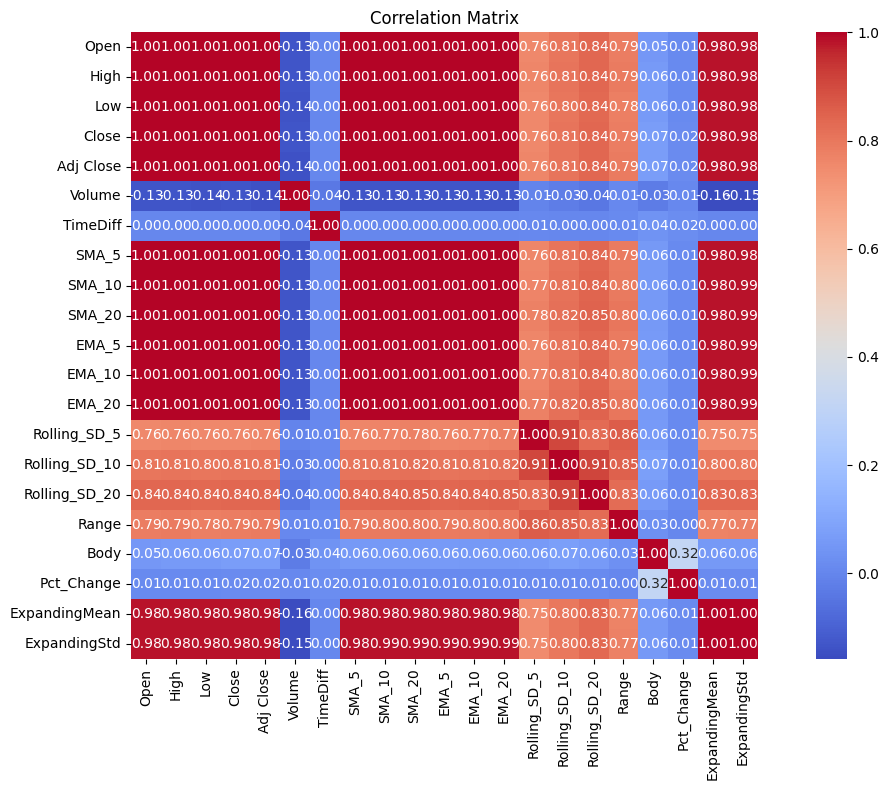

In [7]:
# Correlation Matrix to determine multicollinearity
corr_matrix = df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [8]:
SEQ_LENGTH = 40 # Sequence length in days

# Creates and stores all the input sequences and its labels
def create_sequences(X, y, seq_length=SEQ_LENGTH):
    Xs, ys = [], []
    for i in range(len(X) - seq_length):
        Xs.append(X[i:i + seq_length])
        ys.append(y[i + seq_length])
    return np.array(Xs), np.array(ys)

In [9]:
def load_and_preprocess_data(filepath):
    df = pd.read_csv(filepath, parse_dates=["Date"]) # Upload file
    df.sort_values("Date", inplace=True)

    # Calculate time difference between days
    df['TimeDiff'] = df['Date'].diff().dt.days.fillna(0).astype(int)

    # Feature Engineering
    df['SMA_5'] = df['Close'].rolling(window=5).mean()
    df['SMA_10'] = df['Close'].rolling(window=10).mean()
    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    df['EMA_5'] = df['Close'].ewm(span=5, adjust=False).mean()
    df['EMA_10'] = df['Close'].ewm(span=10, adjust=False).mean()
    df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()
    df['Rolling_SD_5'] = df['Close'].rolling(window=5).std()
    df['Rolling_SD_10'] = df['Close'].rolling(window=10).std()
    df['Rolling_SD_20'] = df['Close'].rolling(window=20).std()
    df['Range'] = df['High'] - df['Low']
    df['Body'] = df['Close'] - df['Open']
    df['Pct_Change'] = (df['Close'] - df['Open']) / df['Open']
    df['ExpandingMean'] = df['Close'].expanding().mean()
    df['ExpandingStd'] = df['Close'].expanding().std()

    df.dropna(inplace=True)

    # Feature and Target Selection
    features = ['Open', 'Volume', 'TimeDiff',
                'SMA_5', 'SMA_10', 'SMA_20',
                'EMA_5', 'EMA_10', 'EMA_20',
                'Range', 'Body', 'Pct_Change',
                'Rolling_SD_5', 'Rolling_SD_10', 'Rolling_SD_20',
                'ExpandingMean', 'ExpandingStd']
    target = 'Close'

    data = df[features].values
    labels = df[[target]].values

    # Train-test split with 20% test size
    X_train, X_test, y_train, y_test = train_test_split(
        data, labels, test_size=0.2, shuffle=False
    )

    # Normalize/Scale features
    feature_scaler = MinMaxScaler()
    X_train_scaled = feature_scaler.fit_transform(X_train)
    X_test_scaled = feature_scaler.transform(X_test)

    # Normalize/Scale targets
    label_scaler = MinMaxScaler()
    y_train_scaled = label_scaler.fit_transform(y_train)
    y_test_scaled = label_scaler.transform(y_test)

    # Optional add Gaussian Noise to Augment
    #data_train_scaled = add_gaussian_noise(data_train_scaled)
    #data_train_scaled = add_jitter(data_train_scaled)

    return X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, label_scaler

Epoch [10/500] | Train Loss: 0.002204 | Val Loss: 0.035580
Epoch [20/500] | Train Loss: 0.000879 | Val Loss: 0.008856
Epoch [30/500] | Train Loss: 0.000319 | Val Loss: 0.004401
Epoch [40/500] | Train Loss: 0.000245 | Val Loss: 0.003500
Epoch [50/500] | Train Loss: 0.000189 | Val Loss: 0.002678
Epoch [60/500] | Train Loss: 0.000136 | Val Loss: 0.001787
Epoch [70/500] | Train Loss: 0.000114 | Val Loss: 0.001299
Epoch [80/500] | Train Loss: 0.000098 | Val Loss: 0.000701
Epoch [90/500] | Train Loss: 0.000088 | Val Loss: 0.000611
Epoch [100/500] | Train Loss: 0.000077 | Val Loss: 0.000430
Epoch [110/500] | Train Loss: 0.000075 | Val Loss: 0.000349
Epoch [120/500] | Train Loss: 0.000069 | Val Loss: 0.000315
Epoch [130/500] | Train Loss: 0.000062 | Val Loss: 0.000299
Epoch [140/500] | Train Loss: 0.000060 | Val Loss: 0.000307
Epoch [150/500] | Train Loss: 0.000057 | Val Loss: 0.000286
Epoch [160/500] | Train Loss: 0.000057 | Val Loss: 0.000283
Epoch [170/500] | Train Loss: 0.000052 | Val Loss

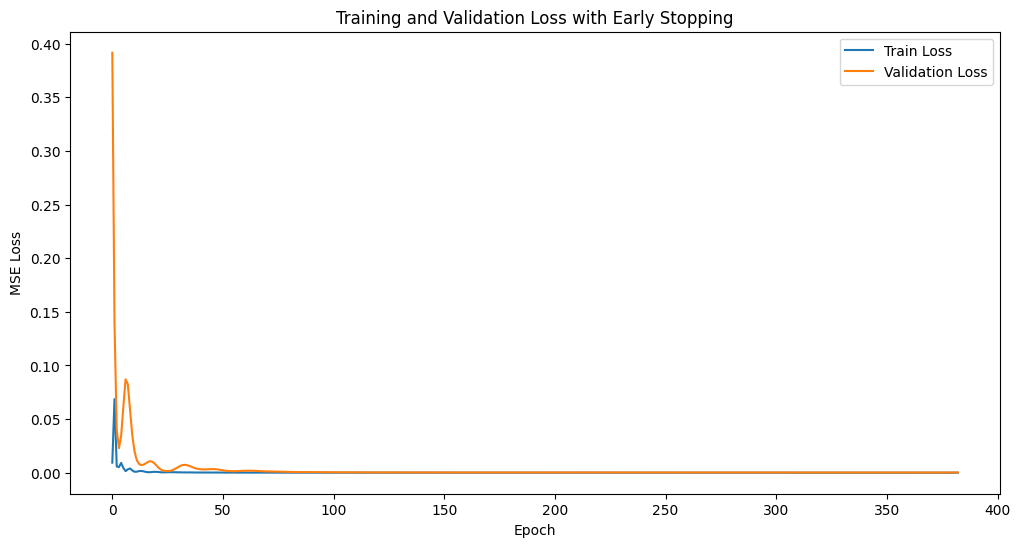

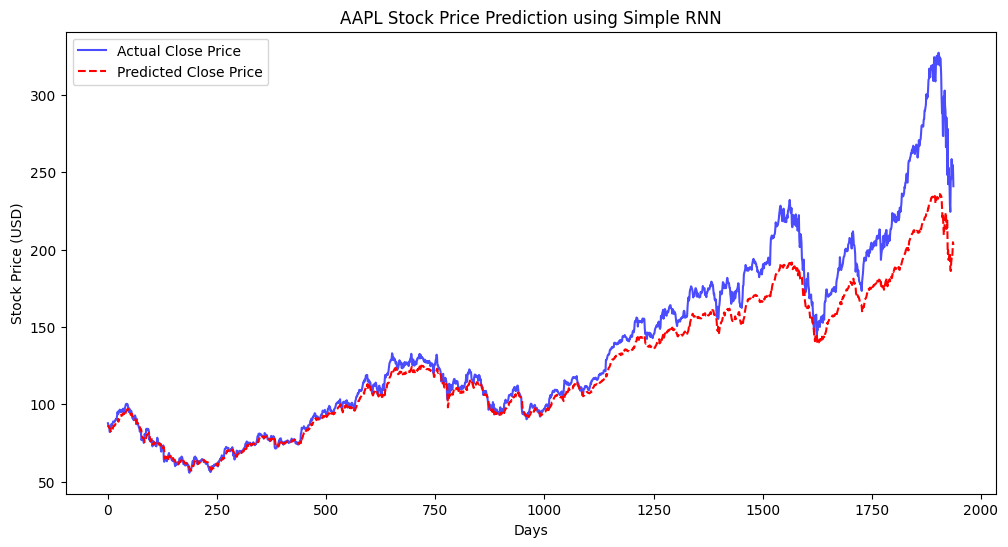

R² Score: 0.8752
Mean Squared Error (MSE): 417.6166
Mean Absolute Error (MAE): 12.1338
Root Mean Squared Error (RMSE): 20.4357
Accuracy within 1%: 11.40%
Accuracy within 2%: 21.36%
Accuracy within 5%: 51.19%
Accuracy within 10%: 77.14%
The projected closing price for the next trading day: $202.99


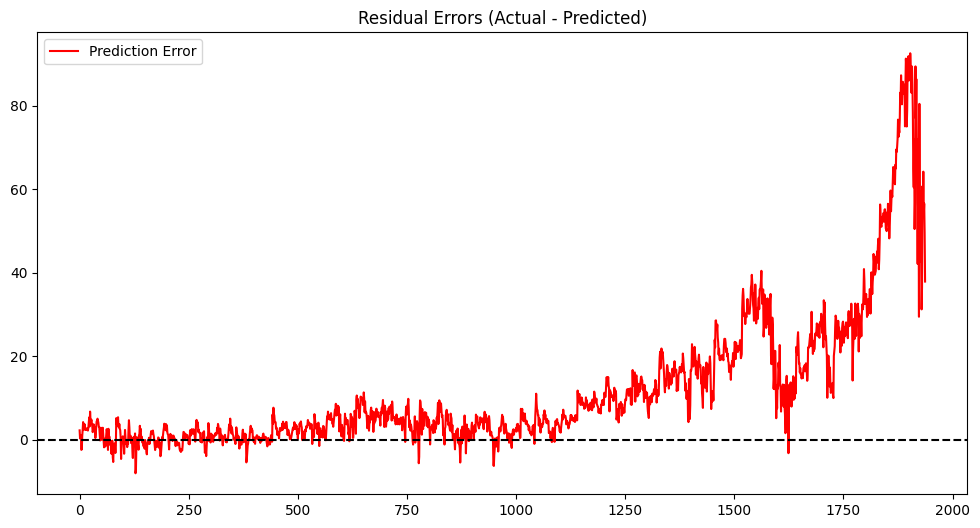

In [11]:
class StockRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1, dropout=0.3):
        super(StockRNN, self).__init__()
        self.hidden_size = hidden_size # Store hidden_size as an attribute
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout) # Dropout/Regularization
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Use self.hidden_size to initialize h0
        h0 = torch.zeros(1, x.size(0), self.hidden_size)  # (num_layers, batch, hidden)
        out, _ = self.rnn(x, h0)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)

def train_model(model, X_train, y_train, X_val, y_val, num_epochs=500, lr=0.005, patience=30):
    start_time = time.time()  # Start timer

    criterion = nn.MSELoss() # Use MSE Loss to train the model
    optimizer = optim.Adam(model.parameters(), lr=lr) # Adam optimizer
    train_losses = []
    val_losses = []

    best_val_loss = float('inf')
    epochs_without_improvement = 0
    best_model_state = None

    for epoch in range(num_epochs):
        # Train step
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        # Validation step
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, y_val)
            val_losses.append(val_loss.item())

        # Early stopping check
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_model_state = model.state_dict()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {loss.item():.6f} | Val Loss: {val_loss.item():.6f}")

        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}. Best Val Loss: {best_val_loss:.6f}")
            break

    # End the timer and print elapsed time
    elapsed_time = time.time() - start_time
    print(f"\nTotal Training Time: {elapsed_time:.2f} seconds")

    # Restore best model weights
    if best_model_state:
        model.load_state_dict(best_model_state)

    # Plot train vs val loss
    plt.figure(figsize=(12, 6))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('Training and Validation Loss with Early Stopping')
    plt.legend()
    plt.show()

    return model


def main():
    X_train_raw, y_train_raw, X_test_raw, y_test_raw, scaler = load_and_preprocess_data("AAPL.csv")

    # Create sequences
    X_train_seq, y_train_seq = create_sequences(X_train_raw, y_train_raw)
    X_test_seq, y_test_seq = create_sequences(X_test_raw, y_test_raw)

    # Convert to tensor
    X_train_seq = torch.tensor(X_train_seq, dtype=torch.float32)
    y_train_seq = torch.tensor(y_train_seq, dtype=torch.float32)
    X_test_seq = torch.tensor(X_test_seq, dtype=torch.float32)
    y_test_seq = torch.tensor(y_test_seq, dtype=torch.float32)

    # Split train into train/val
    val_size = int(0.1 * len(X_train_seq))
    X_val = X_train_seq[-val_size:]
    y_val = y_train_seq[-val_size:]
    X_train_seq = X_train_seq[:-val_size]
    y_train_seq = y_train_seq[:-val_size]

    # Build and train model
    model = StockRNN(input_size=X_train_seq.shape[2], hidden_size=100, output_size=1)
    model = train_model(model, X_train_seq, y_train_seq, X_val, y_val)

    # Evaluate
    evaluate_model(model, X_test_seq, y_test_seq, scaler)


def evaluate_model(model, X_test, y_test, scaler):
    # Predicts test set
    model.eval()
    predictions = model(X_test).detach().numpy()
    actual = y_test.detach().cpu().numpy()

    # Inverse transform
    predictions = scaler.inverse_transform(predictions)
    actual = scaler.inverse_transform(actual)

    # Plot actual vs prediction
    plt.figure(figsize=(12, 6))
    plt.plot(actual, label='Actual Close Price', color='blue', alpha=0.7)
    plt.plot(predictions, label='Predicted Close Price', color='red', linestyle='--')
    plt.legend()
    plt.title('AAPL Stock Price Prediction using Simple RNN')
    plt.xlabel('Days')
    plt.ylabel('Stock Price (USD)')
    plt.show()

    # Metrics
    # R^2 score
    r2 = r2_score(actual, predictions)
    print(f"R² Score: {r2:.4f}")

    # Mean Squared Error (MSE)
    mse = np.mean((actual - predictions) ** 2)
    print(f"Mean Squared Error (MSE): {mse:.4f}")

    # Mean Absolute Error (MAE)
    mae = np.mean(np.abs(actual - predictions))
    print(f"Mean Absolute Error (MAE): {mae:.4f}")

    # Root Mean Squared Error (RMSE)
    rmse = np.sqrt(mse)
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")


    # Accuracy within percentage margins
    def accuracy_within_margin(actual, predicted, margin_percent):
        margin = (margin_percent / 100) * actual
        correct = np.abs(actual - predicted) <= margin
        return np.mean(correct) * 100

    for pct in [1, 2, 5, 10]:
        acc = accuracy_within_margin(actual, predictions, pct)
        print(f"Accuracy within {pct}%: {acc:.2f}%")

    # Project next day's closing price
    last_sequence = X_test[-1].unsqueeze(0)  # Add batch dimension
    next_day_scaled = model(last_sequence).detach().numpy()
    next_day_price = scaler.inverse_transform(next_day_scaled)[0][0]
    print(f"The projected closing price for the next trading day: ${next_day_price:.2f}")



    # Plot residuals
    plt.figure(figsize=(12, 6))
    plt.plot(actual - predictions, label='Prediction Error', color='red')
    plt.axhline(y=0, color='black', linestyle='--')
    plt.title('Residual Errors (Actual - Predicted)')
    plt.legend()
    plt.show()


if __name__ == "__main__":
    main()